# Error-Clustering Analysis: What Protein Properties Do the Models Struggle With?

Unsupervised clustering over per-protein structural, chemical, and geometric
properties (from `/home/student/thesis/outputs/protein_master_dataset.csv`, built by
`scripts/build_protein_master_csv.py`) to find what characterizes the
proteins the two full-dataset champion models predict poorly.

**Scope:**
- Covers the two full-dataset champions only: `attention_aa4_aq2_qq16` and
  `distance_aa8_aq2_qq24` (see `checkpoints/full_dataset/`).
- **AlphaFold-confidence fields (pLDDT, per-residue confidence) are
  deliberately excluded** — a separate notebook will cover AlphaFold
  structural uncertainty specifically. Everything here is a geometric,
  chemical, or physical property of the *predicted structure itself*, not
  of AlphaFold's confidence in it.
- Restricted to the 848-protein test split — the only proteins with
  per-protein model error metrics.


In [1]:
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal, mannwhitneyu, spearmanr
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import umap

sys.path.insert(0, str(Path("..").resolve()))

RANDOM_STATE = 42
THESIS_ROOT  = Path("/home/student/thesis")


/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Load Master CSV

In [2]:
df = pd.read_csv("/home/student/thesis/outputs/protein_master_dataset.csv")
print(f"Master CSV: {len(df):,} proteins x {len(df.columns)} columns")

df_test = df[df["split"] == "test"].reset_index(drop=True)
assert len(df_test) == 848, f"Expected 848 test proteins, got {len(df_test)}"
print(f"Test split: {len(df_test):,} proteins (the only ones with model metrics)")

df_test.info()


Master CSV: 8,461 proteins x 52 columns
Test split: 848 proteins (the only ones with model metrics)
<class 'pandas.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   protein_id                    848 non-null    str    
 1   uniprot_id                    848 non-null    str    
 2   protein_name                  848 non-null    str    
 3   organism                      848 non-null    str    
 4   split                         848 non-null    str    
 5   sequence_length               848 non-null    int64  
 6   n_heavy_atoms                 848 non-null    int64  
 7   net_charge                    848 non-null    float64
 8   ses_area                      848 non-null    float64
 9   n_vertices                    848 non-null    int64  
 10  n_query_nodes                 848 non-null    int64  
 11  interp_pearson_r              848 

In [3]:
# Defensive re-check on top of build_protein_master_csv.py's own contamination
# gate: no graph-stat column should be NaN within the labeled test subset,
# and every test protein should have both models' metrics.
graph_stat_cols = [
    "num_atom_nodes", "num_nodes_total", "num_bond_edges",
    "num_radial_edges", "num_aq_edges", "num_qq_edges", "num_edges_total",
]
model_metric_cols = [c for c in df_test.columns if c.startswith(("attention_", "distance_"))]

n_missing_graph_stats = df_test[graph_stat_cols].isna().any(axis=1).sum()
n_missing_metrics     = df_test[model_metric_cols].isna().any(axis=1).sum()
print(f"Test rows with any missing graph-stat column: {n_missing_graph_stats}")
print(f"Test rows with any missing model-metric column: {n_missing_metrics}")
assert n_missing_graph_stats == 0, "Run scripts/repair_graph_stats.py first."
assert n_missing_metrics == 0, "Every test-split protein should have both models' metrics."


Test rows with any missing graph-stat column: 0
Test rows with any missing model-metric column: 0


---
## 2. Feature Columns vs. Error Columns

`FEATURE_COLS` are what clustering sees — structural, chemical, and
geometric properties of each protein, plus its graph size and the
non-learned RBF-interpolation baseline's own accuracy (a protein-intrinsic
"how hard is this task" signal, not derived from either trained model).

`ERROR_COLS` are what we're trying to explain — never fed into clustering,
only used afterward to interpret what the clusters (or raw correlations)
found.

These two lists must never overlap.

In [4]:
FEATURE_COLS = [
    "sequence_length", "n_heavy_atoms", "net_charge", "ses_area",
    "n_vertices", "n_query_nodes",
    "interp_pearson_r", "interp_rmse",
    "esp_min", "esp_max", "esp_mean", "esp_std",
    "dipole_x", "dipole_y", "dipole_z", "dipole_magnitude",
    "radius_of_gyration", "asphericity", "acylindricity",
    "hydrophobic_fraction", "charged_fraction", "polar_fraction",
    "volume_A3", "surface_to_volume", "volume_per_atom",
    "area_per_atom", "normalized_area",
    "num_atom_nodes", "num_nodes_total", "num_bond_edges",
    "num_radial_edges", "num_aq_edges", "num_qq_edges", "num_edges_total",
]

ERROR_COLS = [
    "attention_rmse", "attention_mae", "attention_pearson_r",
    "attention_morans_i", "attention_esp_error_spearman",
    "distance_rmse", "distance_mae", "distance_pearson_r",
    "distance_morans_i", "distance_esp_error_spearman",
]

assert not (set(FEATURE_COLS) & set(ERROR_COLS)), "FEATURE_COLS and ERROR_COLS must not overlap"
assert all(c in df_test.columns for c in FEATURE_COLS + ERROR_COLS)
print(f"{len(FEATURE_COLS)} feature columns, {len(ERROR_COLS)} error columns")


34 feature columns, 10 error columns


---
## 3. Size-Normalized Error

Protein size (node/edge counts, sequence length, volume) turns out to
correlate strongly with raw RMSE later in this notebook. One explanation:
bigger proteins may simply have bigger raw ESP swings (`esp_std`), which
mechanically inflates *absolute* RMSE even if the model is doing an equally
good job in relative terms. Dividing RMSE by each protein's own ESP scale
tests this directly.

- **`rmse_norm_std` (primary)**: RMSE divided by `esp_std` — a
  distributional statistic, robust to single-vertex outliers. This codebase
  already has dedicated tooling for ESP-artifact outlier vertices
  (`scripts/diagnose_esp_artifacts.py`, `scripts/fix_esp_artifacts.py`),
  which is exactly the kind of single-vertex spike a range-based normalizer
  would be more sensitive to.
- **`rmse_norm_range` (secondary sensitivity check)**: RMSE divided by
  `esp_max - esp_min`. More outlier-prone since min/max are single-vertex
  values, kept as a cross-check rather than the primary read.
- **Pearson r is left alone** — it's already scale-invariant (computed from
  standardized covariance), so normalizing it would be a no-op up to noise.
- **Caveat**: `esp_std`/`esp_min`/`esp_max` are computed from `esp_faces`
  (face-averaged ESP), not `esp_verts` — a very slight smoothing, not
  expected to matter here but worth knowing.

In [5]:
for prefix in ("attention", "distance"):
    df_test[f"{prefix}_rmse_norm_std"]   = df_test[f"{prefix}_rmse"] / df_test["esp_std"]
    df_test[f"{prefix}_rmse_norm_range"] = df_test[f"{prefix}_rmse"] / (df_test["esp_max"] - df_test["esp_min"])

norm_cols = [c for c in df_test.columns if c.endswith(("_norm_std", "_norm_range"))]
print("New normalized columns:", norm_cols)
df_test[["attention_rmse", "attention_rmse_norm_std", "attention_rmse_norm_range",
         "distance_rmse", "distance_rmse_norm_std", "distance_rmse_norm_range"]].describe().round(4)


New normalized columns: ['attention_rmse_norm_std', 'attention_rmse_norm_range', 'distance_rmse_norm_std', 'distance_rmse_norm_range']


,attention_rmse,attention_rmse_norm_std,attention_rmse_norm_range,distance_rmse,distance_rmse_norm_std,distance_rmse_norm_range
count,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000
mean,1.5034,0.5071,0.0587,1.4149,0.4791,0.0557
std,0.8398,0.2648,0.0314,0.7522,0.2424,0.0294
min,0.4189,0.1417,0.0219,0.3889,0.1509,0.0192
25%,0.9743,0.3472,0.0394,0.9408,0.3286,0.0375
50%,1.2633,0.4287,0.0495,1.2326,0.4181,0.0476
75%,1.7445,0.5674,0.0668,1.6270,0.5316,0.0628
max,7.3632,2.1059,0.2992,6.4425,1.9303,0.2899


---
## 4. Direct Correlation: Structural Properties vs. Model Error

Before clustering, the fastest signal: Spearman correlation (robust to the
very different scales and non-linear relationships here — edge counts in
the thousands, unitless fractions, Å² areas) between every feature and each
champion's `rmse`/`pearson_r` — raw and size-normalized side by side. If
`interp_pearson_r`/`interp_rmse` (the non-learned RBF baseline's own
difficulty) correlates with model error more strongly than any specific
geometric or chemical property, that's a sign high error is mostly about
intrinsic task difficulty rather than a learnable blind spot.

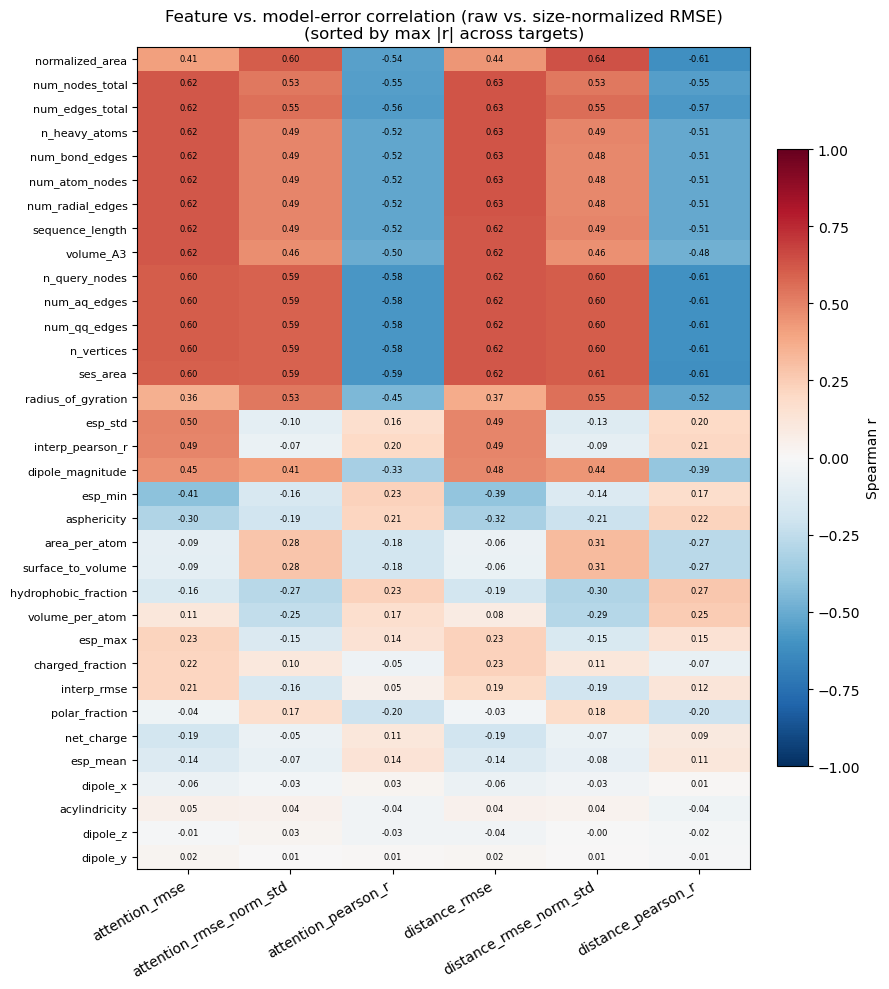


Top 10 |correlation| with attention_rmse:
num_nodes_total     0.623
n_heavy_atoms       0.623
num_bond_edges      0.622
num_atom_nodes      0.622
num_radial_edges    0.622
volume_A3           0.621
num_edges_total     0.619
sequence_length     0.617
n_query_nodes       0.604
num_aq_edges        0.604
Name: attention_rmse, dtype: float64

Top 10 |correlation| with attention_rmse_norm_std:
normalized_area       0.604
ses_area              0.593
num_qq_edges          0.589
n_query_nodes         0.589
num_aq_edges          0.589
n_vertices            0.589
num_edges_total       0.549
num_nodes_total       0.528
radius_of_gyration    0.528
n_heavy_atoms         0.488
Name: attention_rmse_norm_std, dtype: float64

Top 10 |correlation| with attention_pearson_r:
ses_area           0.585
n_query_nodes      0.584
num_qq_edges       0.584
num_aq_edges       0.584
n_vertices         0.584
num_edges_total    0.562
num_nodes_total    0.548
normalized_area    0.540
sequence_length    0.520
n_heavy_a

In [6]:
CORR_TARGETS = [
    "attention_rmse", "attention_rmse_norm_std", "attention_pearson_r",
    "distance_rmse",  "distance_rmse_norm_std",  "distance_pearson_r",
]

corr = pd.DataFrame(
    {target: [spearmanr(df_test[f], df_test[target]).correlation for f in FEATURE_COLS]
     for target in CORR_TARGETS},
    index=FEATURE_COLS,
)
corr_sorted = corr.reindex(corr.abs().max(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(corr_sorted.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(CORR_TARGETS)))
ax.set_xticklabels(CORR_TARGETS, rotation=30, ha="right")
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index, fontsize=8)
for i in range(len(corr_sorted)):
    for j in range(len(CORR_TARGETS)):
        ax.text(j, i, f"{corr_sorted.values[i, j]:.2f}", ha="center", va="center", fontsize=6)
plt.colorbar(im, ax=ax, label="Spearman r", fraction=0.046, pad=0.04)
ax.set_title("Feature vs. model-error correlation (raw vs. size-normalized RMSE)\n(sorted by max |r| across targets)")
plt.tight_layout()
plt.show()

for target in CORR_TARGETS:
    print(f"\nTop 10 |correlation| with {target}:")
    print(corr[target].abs().sort_values(ascending=False).head(10).round(3))


In [7]:
# Does normalizing change the picture for the known size-proxy features specifically?
SIZE_PROXY_FEATURES = [
    "num_nodes_total", "n_heavy_atoms", "sequence_length",
    "volume_A3", "n_vertices", "ses_area",
]

rows = []
for f in SIZE_PROXY_FEATURES:
    row = {"feature": f}
    for prefix in ("attention", "distance"):
        r_raw  = spearmanr(df_test[f], df_test[f"{prefix}_rmse"]).correlation
        r_norm = spearmanr(df_test[f], df_test[f"{prefix}_rmse_norm_std"]).correlation
        row[f"{prefix}_r_raw"]  = r_raw
        row[f"{prefix}_r_norm"] = r_norm
        row[f"{prefix}_delta"]  = r_norm - r_raw
    rows.append(row)

size_proxy_table = pd.DataFrame(rows).set_index("feature").round(3)
print("Size-proxy feature correlation with error: raw RMSE vs. size-normalized RMSE")
print("(delta near 0 -> size effect survives normalization; delta shrinks r toward 0 -> partly a units artifact)")
display(size_proxy_table)


Size-proxy feature correlation with error: raw RMSE vs. size-normalized RMSE
(delta near 0 -> size effect survives normalization; delta shrinks r toward 0 -> partly a units artifact)


,attention_r_raw,attention_r_norm,attention_delta,distance_r_raw,distance_r_norm,distance_delta
feature,,,,,,
num_nodes_total,0.623,0.528,-0.094,0.631,0.531,-0.100
n_heavy_atoms,0.623,0.488,-0.135,0.626,0.485,-0.141
sequence_length,0.617,0.488,-0.129,0.621,0.486,-0.136
volume_A3,0.621,0.461,-0.159,0.621,0.455,-0.166
n_vertices,0.604,0.589,-0.015,0.620,0.602,-0.018
ses_area,0.601,0.593,-0.008,0.618,0.608,-0.010


---
## 5. Standardize Features

Distance-based methods (PCA, t-SNE, UMAP, KMeans, DBSCAN, Agglomerative)
all use Euclidean distance on the raw feature values — without scaling,
`num_edges_total` (tens of thousands) would completely dominate
`hydrophobic_fraction` (0-1) regardless of which one actually matters more.
`StandardScaler` z-scores every feature to mean 0, std 1.

In [8]:
X_raw = df_test[FEATURE_COLS].to_numpy()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f"X shape: {X.shape}")


X shape: (848, 34)


---
## 6. PCA

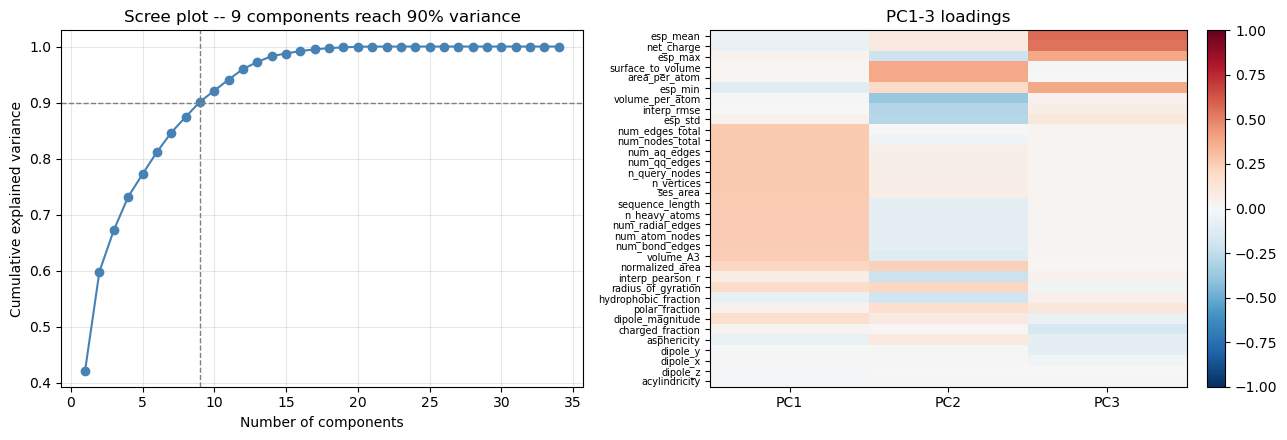

PC1 explains 42.2% of variance alone.
Top |loading| features per PC:
  PC1: ['num_edges_total', 'num_nodes_total', 'num_aq_edges', 'num_qq_edges', 'n_query_nodes']
  PC2: ['surface_to_volume', 'area_per_atom', 'volume_per_atom', 'interp_rmse', 'esp_std']
  PC3: ['esp_mean', 'net_charge', 'esp_max', 'esp_min', 'charged_fraction']

Reduced to 9 PCA components for downstream embedding/clustering.


In [9]:
pca = PCA(random_state=RANDOM_STATE).fit(X)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_90 = int(np.searchsorted(cum_var, 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(1, len(cum_var) + 1), cum_var, "o-", color="steelblue")
axes[0].axhline(0.90, color="gray", ls="--", lw=1)
axes[0].axvline(n_90, color="gray", ls="--", lw=1)
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title(f"Scree plot -- {n_90} components reach 90% variance")
axes[0].grid(alpha=0.3)

loadings = pd.DataFrame(pca.components_[:3].T, index=FEATURE_COLS, columns=["PC1", "PC2", "PC3"])
loadings_sorted = loadings.reindex(loadings.abs().max(axis=1).sort_values(ascending=False).index)
im = axes[1].imshow(loadings_sorted.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(["PC1", "PC2", "PC3"])
axes[1].set_yticks(range(len(loadings_sorted)))
axes[1].set_yticklabels(loadings_sorted.index, fontsize=7)
axes[1].set_title("PC1-3 loadings")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance alone.")
print("Top |loading| features per PC:")
for pc in ["PC1", "PC2", "PC3"]:
    print(f"  {pc}: {loadings[pc].abs().sort_values(ascending=False).head(5).index.tolist()}")

X_pca = PCA(n_components=n_90, random_state=RANDOM_STATE).fit_transform(X)
print(f"\nReduced to {n_90} PCA components for downstream embedding/clustering.")


---
## 7. UMAP + t-SNE -- 2D Visualization

/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


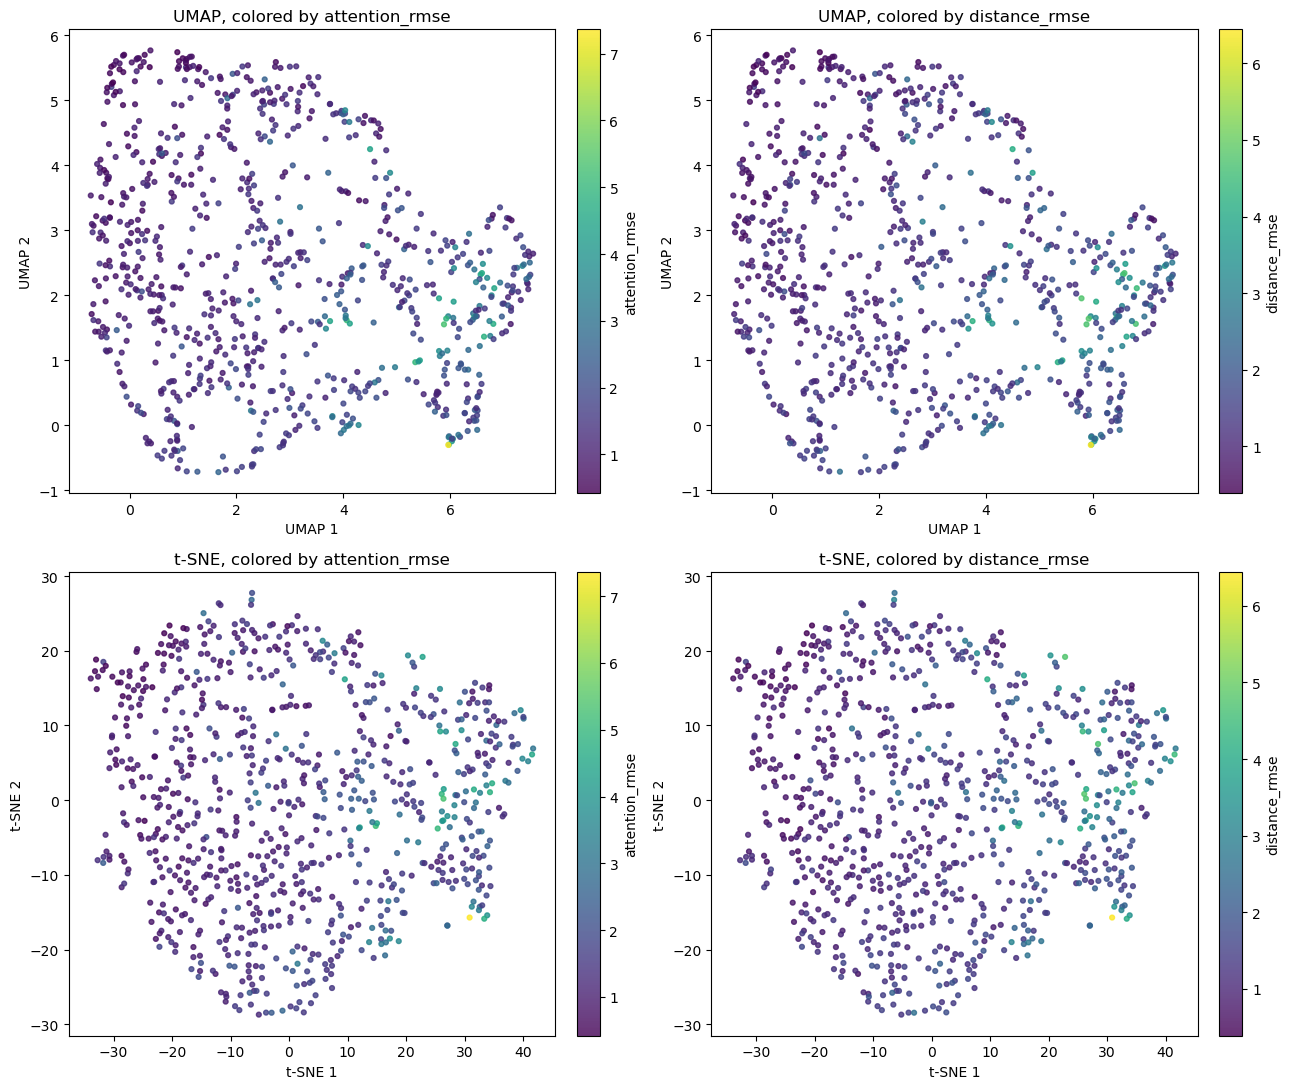

In [10]:
embedding_umap = umap.UMAP(random_state=RANDOM_STATE).fit_transform(X_pca)
embedding_tsne = TSNE(random_state=RANDOM_STATE, init="pca").fit_transform(X_pca)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for row, (name, emb) in enumerate([("UMAP", embedding_umap), ("t-SNE", embedding_tsne)]):
    for col, target in enumerate(["attention_rmse", "distance_rmse"]):
        ax = axes[row, col]
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=df_test[target], cmap="viridis", s=12, alpha=0.8)
        plt.colorbar(sc, ax=ax, label=target, fraction=0.046, pad=0.04)
        ax.set_title(f"{name}, colored by {target}")
        ax.set_xlabel(f"{name} 1")
        ax.set_ylabel(f"{name} 2")
plt.tight_layout()
plt.show()


---
## 8. Clustering

Three methods, each catching something the others might miss:
- **KMeans** -- convex clusters, k chosen via elbow + silhouette.
- **DBSCAN** -- density-based; naturally labels outlier proteins as noise
  (`-1`) rather than forcing them into the nearest cluster.
- **Agglomerative** (hierarchical) -- mirrors the dendrogram style already
  used for residue clustering in
  `notebooks/decisions/16_attention_head_analysis.ipynb` §11.

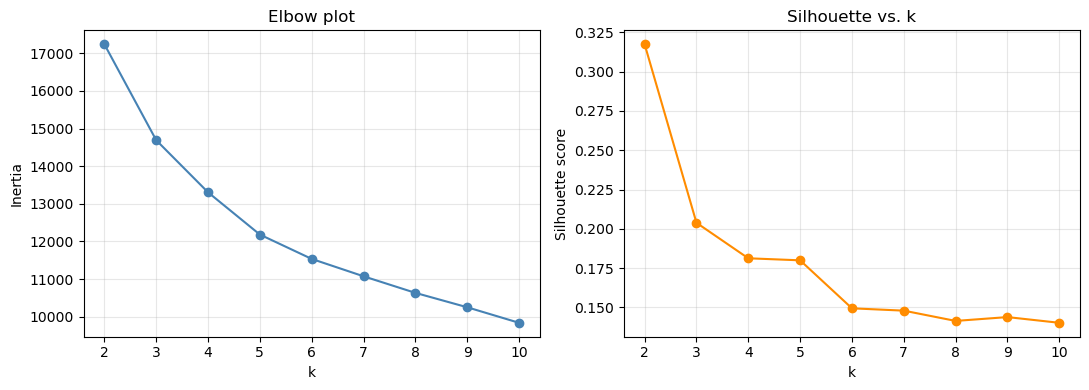

Best silhouette at k=2 (score=0.317)


In [11]:
k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, "o-", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow plot")
axes[0].grid(alpha=0.3)
axes[1].plot(list(k_range), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette vs. k")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

K_CHOSEN = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best silhouette at k={K_CHOSEN} (score={max(silhouettes):.3f})")

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
df_test["cluster_kmeans"] = kmeans.labels_


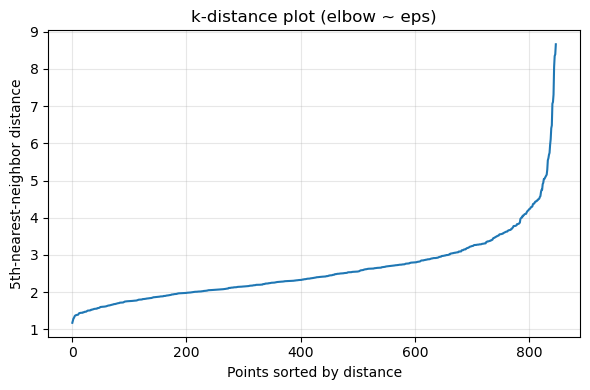

eps=3.64: 1 clusters, 47 noise/outlier proteins


In [12]:
k_dist = np.sort(NearestNeighbors(n_neighbors=5).fit(X_pca).kneighbors(X_pca)[0][:, -1])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_dist)
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel("5th-nearest-neighbor distance")
ax.set_title("k-distance plot (elbow ~ eps)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

EPS_CHOSEN = float(np.percentile(k_dist, 90))  # heuristic starting point off the plot above
dbscan = DBSCAN(eps=EPS_CHOSEN, min_samples=5).fit(X_pca)
df_test["cluster_dbscan"] = dbscan.labels_
n_noise = int((dbscan.labels_ == -1).sum())
n_clusters_dbscan = len(set(dbscan.labels_)) - (1 if n_noise else 0)
print(f"eps={EPS_CHOSEN:.2f}: {n_clusters_dbscan} clusters, {n_noise} noise/outlier proteins")


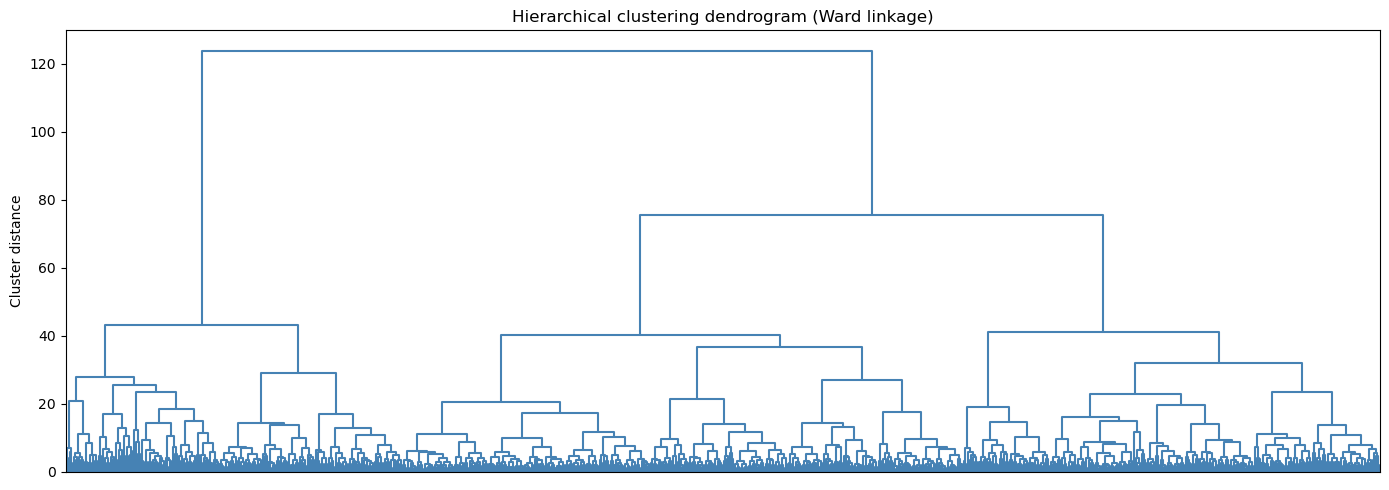

Agglomerative: cut at 2 clusters (matching KMeans' k for direct comparison)


In [13]:
Z = linkage(X_pca, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color="steelblue")
ax.set_title("Hierarchical clustering dendrogram (Ward linkage)")
ax.set_ylabel("Cluster distance")
plt.tight_layout()
plt.show()

agg = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward").fit(X_pca)
df_test["cluster_agg"] = agg.labels_
print(f"Agglomerative: cut at {K_CHOSEN} clusters (matching KMeans' k for direct comparison)")


---
## 9. Cross-Algorithm Agreement

There's no external "known chemistry" label for proteins the way there was
for residues in notebook 16 §12 -- so instead we check whether the three
clustering methods above agree with *each other*. High ARI/NMI means the
cluster structure is real and robust to the choice of algorithm; low scores
mean any apparent structure is method-dependent and should be treated with
caution. DBSCAN's noise points (`-1`) are excluded from this comparison --
they aren't cluster membership.

In [14]:
not_noise = df_test["cluster_dbscan"] != -1

pairs = [
    ("KMeans vs Agglomerative", df_test["cluster_kmeans"], df_test["cluster_agg"]),
    ("KMeans vs DBSCAN",        df_test.loc[not_noise, "cluster_kmeans"], df_test.loc[not_noise, "cluster_dbscan"]),
    ("Agglomerative vs DBSCAN", df_test.loc[not_noise, "cluster_agg"],    df_test.loc[not_noise, "cluster_dbscan"]),
]

rows = []
for name, a, b in pairs:
    rows.append({"Comparison": name, "ARI": adjusted_rand_score(a, b), "NMI": normalized_mutual_info_score(a, b)})
display(pd.DataFrame(rows).round(3))


,Comparison,ARI,NMI
0,KMeans vs Agglomerative,0.601,0.527
1,KMeans vs DBSCAN,0.000,0.000
2,Agglomerative vs DBSCAN,0.000,0.000


---
## 10. Per-Cluster Profiling (KMeans)

Using KMeans as the primary clustering (best silhouette by construction).
For each cluster: mean z-scored feature profile, mean/median error per
model, and whether the error differences across clusters are statistically
significant (Kruskal-Wallis -- no assumption of normal/equal-variance
error distributions, which is not a safe assumption here).

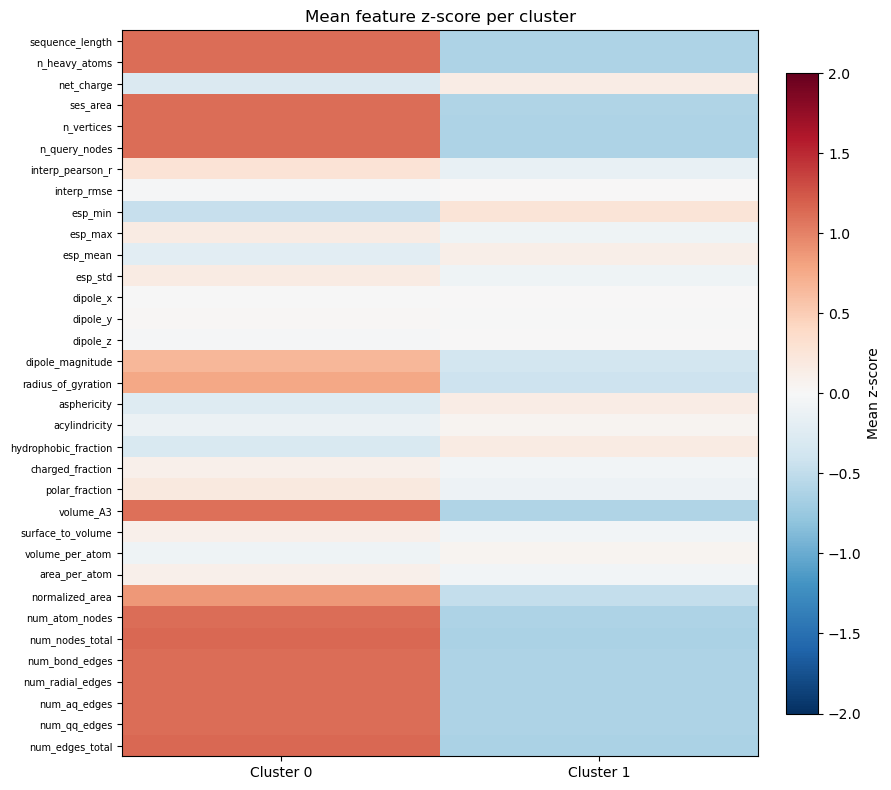

Cluster sizes:
cluster_kmeans
0    300
1    548
Name: count, dtype: int64


In [15]:
X_scaled_df = pd.DataFrame(X, columns=FEATURE_COLS, index=df_test.index)
cluster_profile = X_scaled_df.groupby(df_test["cluster_kmeans"]).mean()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cluster_profile.T.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(K_CHOSEN))
ax.set_xticklabels([f"Cluster {i}" for i in range(K_CHOSEN)])
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
plt.colorbar(im, ax=ax, label="Mean z-score", fraction=0.046, pad=0.04)
ax.set_title("Mean feature z-score per cluster")
plt.tight_layout()
plt.show()

print("Cluster sizes:")
print(df_test["cluster_kmeans"].value_counts().sort_index())


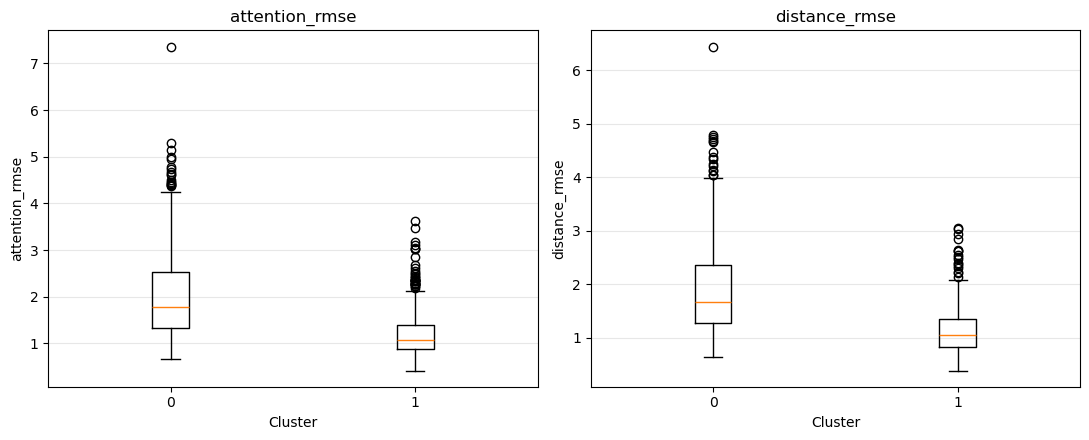

Kruskal-Wallis test (error differs across clusters?):
  attention_rmse          H=223.10  p=1.90e-50  significant
  attention_pearson_r     H=190.47  p=2.51e-43  significant
  distance_rmse           H=233.17  p=1.22e-52  significant
  distance_pearson_r      H=182.64  p=1.29e-41  significant


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, target in zip(axes, ["attention_rmse", "distance_rmse"]):
    groups = [df_test.loc[df_test["cluster_kmeans"] == c, target] for c in range(K_CHOSEN)]
    ax.boxplot(groups, tick_labels=[str(c) for c in range(K_CHOSEN)])
    ax.set_xlabel("Cluster")
    ax.set_ylabel(target)
    ax.set_title(target)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Kruskal-Wallis test (error differs across clusters?):")
for target in ["attention_rmse", "attention_pearson_r", "distance_rmse", "distance_pearson_r"]:
    groups = [df_test.loc[df_test["cluster_kmeans"] == c, target] for c in range(K_CHOSEN)]
    h, p = kruskal(*groups)
    print(f"  {target:<22}  H={h:.2f}  p={p:.2e}  {'significant' if p < 0.05 else 'not significant'}")


In [17]:
def posthoc_mannwhitney(df, group_col, target, n_groups, alpha=0.05):
    """Pairwise Mann-Whitney U with Bonferroni correction across all cluster pairs."""
    pairs = list(combinations(range(n_groups), 2))
    alpha_corrected = alpha / len(pairs)
    rows = []
    for a, b in pairs:
        x = df.loc[df[group_col] == a, target]
        y = df.loc[df[group_col] == b, target]
        stat, p = mannwhitneyu(x, y)
        rows.append({"pair": f"{a} vs {b}", "p": p, "significant": p < alpha_corrected})
    return pd.DataFrame(rows), alpha_corrected

for target in ["attention_rmse", "distance_rmse"]:
    posthoc_df, alpha_corr = posthoc_mannwhitney(df_test, "cluster_kmeans", target, K_CHOSEN)
    n_sig = posthoc_df["significant"].sum()
    print(f"\n{target} -- Bonferroni-corrected alpha={alpha_corr:.4f}, "
          f"{n_sig}/{len(posthoc_df)} cluster pairs significantly different:")
    display(posthoc_df[posthoc_df["significant"]])



attention_rmse -- Bonferroni-corrected alpha=0.0500, 1/1 cluster pairs significantly different:


,pair,p,significant
0,0 vs 1,1.907106e-50,True



distance_rmse -- Bonferroni-corrected alpha=0.0500, 1/1 cluster pairs significantly different:


,pair,p,significant
0,0 vs 1,1.219187e-52,True


### 10b. Does This Survive Size-Normalization?

The sharper version of the size-normalization question: does the
significant cluster split above (and which cluster is "hardest") hold up
using `rmse_norm_std` instead of raw `rmse` — or does the split partly
dissolve, or the hardest cluster flip, once absolute-magnitude effects are
divided out?

In [18]:
print("Kruskal-Wallis test on SIZE-NORMALIZED RMSE (error differs across clusters?):")
for target in ["attention_rmse_norm_std", "distance_rmse_norm_std"]:
    groups = [df_test.loc[df_test["cluster_kmeans"] == c, target] for c in range(K_CHOSEN)]
    h, p = kruskal(*groups)
    print(f"  {target:<26}  H={h:.2f}  p={p:.2e}  {'significant' if p < 0.05 else 'not significant'}")

cluster_rmse_both = df_test.groupby("cluster_kmeans")[
    ["attention_rmse", "attention_rmse_norm_std", "distance_rmse", "distance_rmse_norm_std"]
].mean()
print("\nMean RMSE per cluster, raw vs. normalized:")
display(cluster_rmse_both.round(4))

hardest_attn_raw  = cluster_rmse_both["attention_rmse"].idxmax()
hardest_attn_norm = cluster_rmse_both["attention_rmse_norm_std"].idxmax()
hardest_dist_raw  = cluster_rmse_both["distance_rmse"].idxmax()
hardest_dist_norm = cluster_rmse_both["distance_rmse_norm_std"].idxmax()
print(f"\nHardest cluster -- attention: raw={hardest_attn_raw}  normalized={hardest_attn_norm}")
print(f"Hardest cluster -- distance:  raw={hardest_dist_raw}  normalized={hardest_dist_norm}")
print("Hardest cluster UNCHANGED by normalization." if (hardest_attn_norm == hardest_attn_raw and hardest_dist_norm == hardest_dist_raw)
      else "Hardest cluster CHANGED under normalization -- the raw-RMSE finding was partly a size/units artifact.")


Kruskal-Wallis test on SIZE-NORMALIZED RMSE (error differs across clusters?):
  attention_rmse_norm_std     H=190.51  p=2.46e-43  significant
  distance_rmse_norm_std      H=194.23  p=3.79e-44  significant

Mean RMSE per cluster, raw vs. normalized:


,attention_rmse,attention_rmse_norm_std,distance_rmse,distance_rmse_norm_std
cluster_kmeans,,,,
0,2.0681,0.6690,1.9344,0.6294
1,1.1942,0.4184,1.1305,0.3968



Hardest cluster -- attention: raw=0  normalized=0
Hardest cluster -- distance:  raw=0  normalized=0
Hardest cluster UNCHANGED by normalization.


---
## 11. Attention vs. Distance -- Same Proteins, or Different?

Do the two architectures struggle on the same proteins, or does each have
its own failure mode?

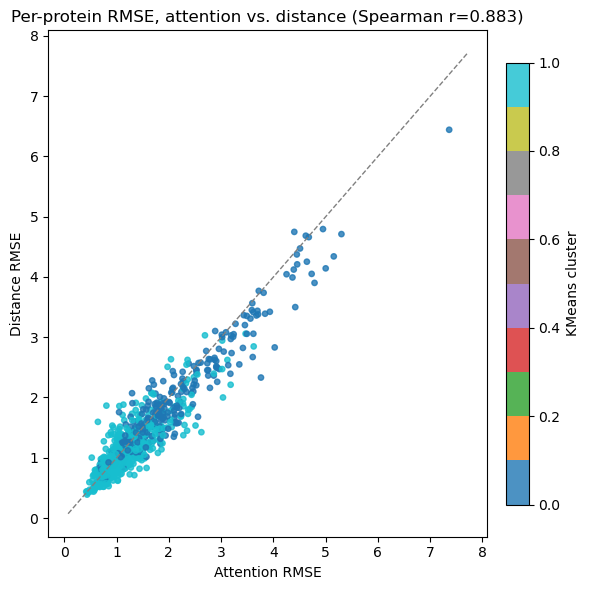

In [19]:
r_delta, p_delta = spearmanr(df_test["attention_rmse"], df_test["distance_rmse"])

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_test["attention_rmse"], df_test["distance_rmse"],
                 c=df_test["cluster_kmeans"], cmap="tab10", s=15, alpha=0.8)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set_xlabel("Attention RMSE")
ax.set_ylabel("Distance RMSE")
ax.set_title(f"Per-protein RMSE, attention vs. distance (Spearman r={r_delta:.3f})")
plt.colorbar(sc, ax=ax, label="KMeans cluster", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


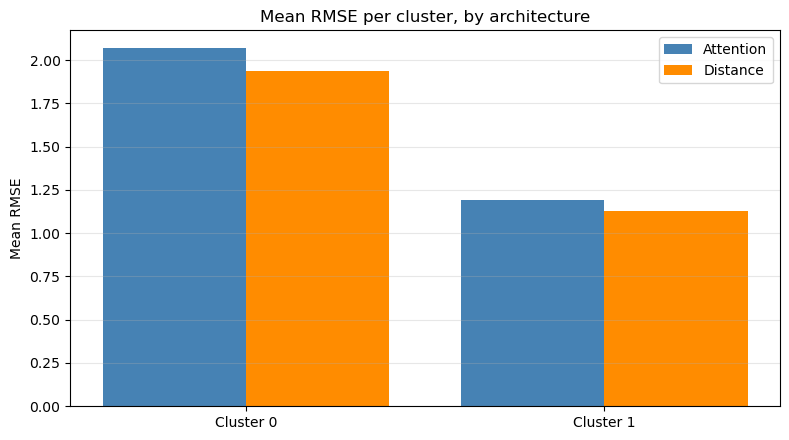

Hardest cluster for attention: 0  (mean RMSE=2.068)
Hardest cluster for distance: 0  (mean RMSE=1.934)
Same cluster is hardest for both.


In [20]:
cluster_rmse = df_test.groupby("cluster_kmeans")[["attention_rmse", "distance_rmse"]].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(K_CHOSEN)
ax.bar(x - 0.2, cluster_rmse["attention_rmse"], width=0.4, label="Attention", color="steelblue")
ax.bar(x + 0.2, cluster_rmse["distance_rmse"], width=0.4, label="Distance", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c}" for c in cluster_rmse.index])
ax.set_ylabel("Mean RMSE")
ax.set_title("Mean RMSE per cluster, by architecture")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

hardest_attn = cluster_rmse["attention_rmse"].idxmax()
hardest_dist = cluster_rmse["distance_rmse"].idxmax()
print(f"Hardest cluster for attention: {hardest_attn}  (mean RMSE={cluster_rmse.loc[hardest_attn, 'attention_rmse']:.3f})")
print(f"Hardest cluster for distance: {hardest_dist}  (mean RMSE={cluster_rmse.loc[hardest_dist, 'distance_rmse']:.3f})")
print("Same cluster is hardest for both." if hardest_attn == hardest_dist
      else "Different clusters are hardest -- architecture-specific struggle.")


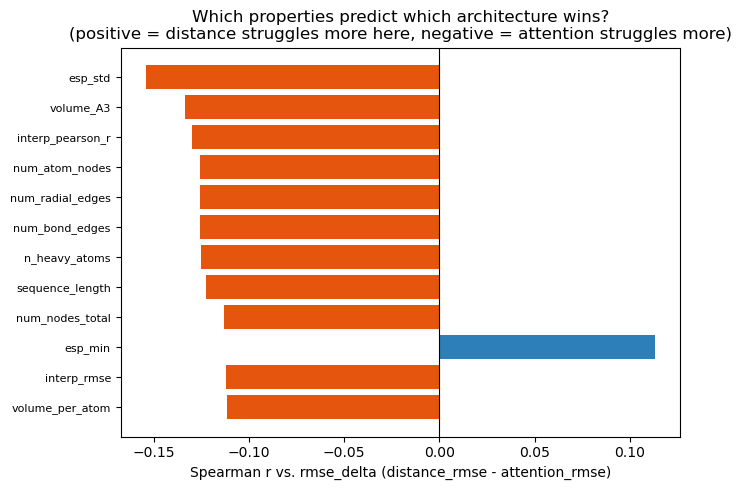

In [21]:
df_test["rmse_delta"] = df_test["distance_rmse"] - df_test["attention_rmse"]

delta_corr = pd.Series(
    {f: spearmanr(df_test[f], df_test["rmse_delta"]).correlation for f in FEATURE_COLS}
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
top = delta_corr.head(12)
colors = ["#2c7fb8" if v > 0 else "#e6550d" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman r vs. rmse_delta (distance_rmse - attention_rmse)")
ax.set_title("Which properties predict which architecture wins?\n"
              "(positive = distance struggles more here, negative = attention struggles more)")
plt.tight_layout()
plt.show()


---
## 12. Size-Bucketed Error Breakdown

§4 already found `sequence_length` correlates with error via a single
Spearman coefficient — this section makes that concrete: bucket the 848
test proteins into 100-residue bins (`[0,100)`, `[100,200)`, ... up to the
longest test protein) and look at mean RMSE/Pearson r bucket by bucket.
The question a single correlation coefficient can't answer: is this a
smooth, roughly monotonic increase across the whole size range, or does
error jump disproportionately at one specific size range (which would be a
more targeted, actionable failure mode than "bigger is harder")?

In [22]:
BIN_WIDTH = 100
n_bins = int(np.ceil((df_test["sequence_length"].max() + 1) / BIN_WIDTH))
edges = [i * BIN_WIDTH for i in range(n_bins + 1)]
bucket_labels = [f"{edges[i]}-{edges[i+1]}" for i in range(len(edges) - 1)]
df_test["size_bucket"] = pd.cut(df_test["sequence_length"], bins=edges, labels=bucket_labels,
                                 right=False, include_lowest=True)

size_bucket_table = df_test.groupby("size_bucket", observed=True).agg(
    n=("protein_id", "count"),
    attention_rmse=("attention_rmse", "mean"),
    attention_pearson_r=("attention_pearson_r", "mean"),
    distance_rmse=("distance_rmse", "mean"),
    distance_pearson_r=("distance_pearson_r", "mean"),
).round(4)
print(f"{size_bucket_table['n'].sum()} proteins across {len(size_bucket_table)} buckets of {BIN_WIDTH} aa "
      f"(sequence_length range: {df_test['sequence_length'].min()}-{df_test['sequence_length'].max()} aa)")
display(size_bucket_table)


848 proteins across 10 buckets of 100 aa (sequence_length range: 22-999 aa)


,n,attention_rmse,attention_pearson_r,distance_rmse,distance_pearson_r
size_bucket,,,,,
0-100,62,0.7901,0.9579,0.7293,0.9628
100-200,132,1.0375,0.9517,1.0082,0.9548
200-300,144,1.1904,0.9477,1.1590,0.9472
300-400,124,1.3788,0.9392,1.2760,0.9397
400-500,88,1.6240,0.9272,1.5480,0.9288
500-600,81,1.7052,0.9349,1.5961,0.9354
600-700,75,2.0049,0.9256,1.8365,0.9278
700-800,51,2.2882,0.9102,2.0967,0.9135
800-900,41,2.0455,0.9170,1.9267,0.9196


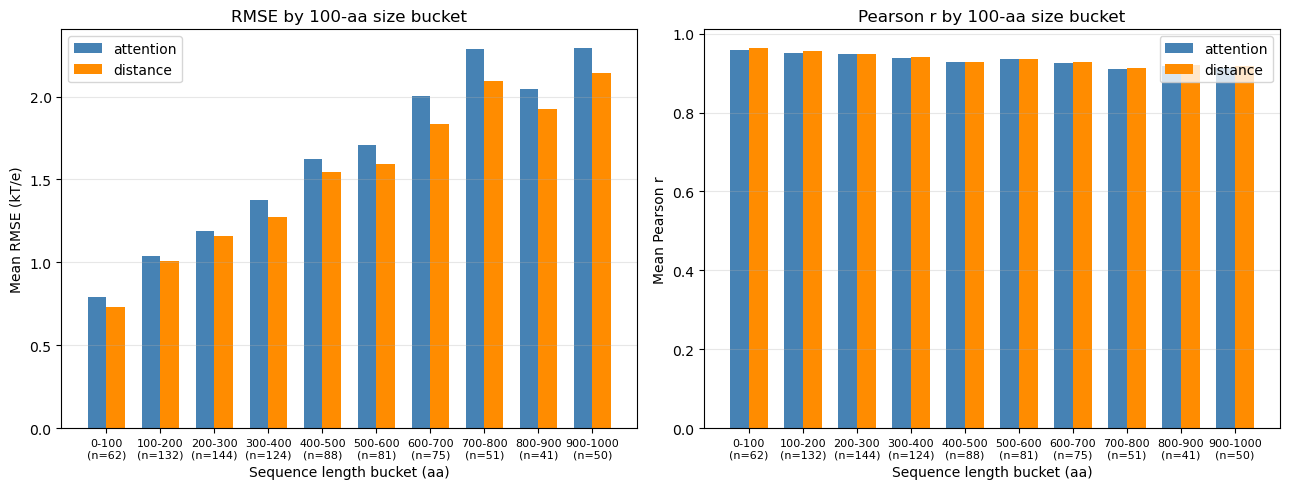

attention: RMSE increases in 8/9 consecutive bucket-to-bucket steps (89% monotonic)
  best bucket:  0-100      RMSE=0.7901
  worst bucket: 900-1000   RMSE=2.2911  (2.90x the best bucket)
distance: RMSE increases in 8/9 consecutive bucket-to-bucket steps (89% monotonic)
  best bucket:  0-100      RMSE=0.7293
  worst bucket: 900-1000   RMSE=2.1451  (2.94x the best bucket)


In [23]:
x = np.arange(len(size_bucket_table))
width = 0.35
x_labels = [f"{idx}\n(n={n})" for idx, n in zip(size_bucket_table.index, size_bucket_table["n"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel, title in [
    (axes[0], "rmse", "Mean RMSE (kT/e)", "RMSE by 100-aa size bucket"),
    (axes[1], "pearson_r", "Mean Pearson r", "Pearson r by 100-aa size bucket"),
]:
    ax.bar(x - width / 2, size_bucket_table[f"attention_{metric}"], width, label="attention", color="steelblue")
    ax.bar(x + width / 2, size_bucket_table[f"distance_{metric}"], width, label="distance", color="darkorange")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_xlabel("Sequence length bucket (aa)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for prefix in ("attention", "distance"):
    rmse_col = f"{prefix}_rmse"
    steps_up = (size_bucket_table[rmse_col].diff().dropna() > 0).sum()
    n_steps  = len(size_bucket_table) - 1
    worst_bucket = size_bucket_table[rmse_col].idxmax()
    best_bucket  = size_bucket_table[rmse_col].idxmin()
    print(f"{prefix}: RMSE increases in {steps_up}/{n_steps} consecutive bucket-to-bucket steps "
          f"({steps_up/n_steps:.0%} monotonic)")
    print(f"  best bucket:  {best_bucket:<10} RMSE={size_bucket_table.loc[best_bucket, rmse_col]:.4f}")
    print(f"  worst bucket: {worst_bucket:<10} RMSE={size_bucket_table.loc[worst_bucket, rmse_col]:.4f}  "
          f"({size_bucket_table.loc[worst_bucket, rmse_col] / size_bucket_table.loc[best_bucket, rmse_col]:.2f}x the best bucket)")


---
## 13. Summary

*Fill in after reviewing the plots and tables above:*

- **Does clustering find a genuinely separable "hard" population, or a
  continuum?** (Silhouette scores from §8, cluster separation in §7's
  UMAP/t-SNE plots.)
- **Which structural/chemical/geometric properties correlate most with
  error** (§4), and do those same properties dominate the highest-error
  cluster's profile (§10)?
- **Do the champions share or diverge in failure modes** (§11)? If
  architecture-specific, which properties predict the difference?
- **Is `interp_pearson_r`/`interp_rmse` (the non-learned baseline's own
  difficulty) doing most of the explanatory work**, or do learned-model-
  specific properties stand out beyond intrinsic task difficulty?
- **Does the size-correlation and hardest-cluster finding survive
  size-normalization** (§3, §10b)? If the normalized-RMSE version tells a
  different story than raw RMSE, that changes how "protein size predicts
  error" should be stated — as a genuine difficulty effect vs. partly a
  units artifact.
- **Is the size effect a smooth trend or bucket-specific** (§12)? Does the
  bucketed view change how "protein size predicts error" should be phrased
  in the thesis — a steady increase vs. a specific size range that's
  disproportionately hard.

**Candidate follow-ups:**
- The deferred AlphaFold-structural-uncertainty notebook (pLDDT vs. error,
  explicitly out of scope here).
- A dedicated per-residue/error-localization notebook, if the clusters
  found here suggest a specific chemical environment (rather than a global
  protein property) is driving error.
- `notebooks/vertex_error_analysis.ipynb` — per-vertex breakdown (query vs.
  interpolated, error buckets by true-ESP range, spatial hotspot detection).